In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/ankushpanjiyar/particle-collision-track-reconstruction/QCDToGGQQ_IMGjet_RH1all_jet0_run0_n36272.test.snappy.parquet
/kaggle/input/datasets/ankushpanjiyar/particle-collision-track-reconstruction/QCDToGGQQ_IMGjet_RH1all_jet0_run1_n47540.test.snappy.parquet
/kaggle/input/datasets/ankushpanjiyar/particle-collision-track-reconstruction/QCDToGGQQ_IMGjet_RH1all_jet0_run2_n55494.test.snappy.parquet


# Graph Neural Networks for Jet Classification (Run1 Dataset)

This notebook extends previous experiments by evaluating graph-based models on a different dataset split (jet0 run1). The goal is to analyze model robustness and consistency across multiple data distributions.

In [2]:
!pip install torch-geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 39.1 MB/s eta 0:00:00


In [3]:
import torch
import torch.nn.functional as F
from torch.nn import Linear, Sequential, ReLU
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GATConv, EdgeConv, global_mean_pool
from sklearn.model_selection import train_test_split
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
from tqdm import tqdm
import random
import pyarrow.parquet as pq

In [4]:
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

## Experimental Setup (Run1)

This notebook follows the same pipeline as the previous experiment (run0), with the key difference being the dataset split.

By keeping the model architecture and preprocessing identical, we isolate the effect of data variation on model performance.

In [5]:
file = "/kaggle/input/datasets/ankushpanjiyar/particle-collision-track-reconstruction/QCDToGGQQ_IMGjet_RH1all_jet0_run1_n47540.test.snappy.parquet"

pf= pq.ParquetFile(file)
print("rows:", pf.metadata.num_rows)
print("columns:", pf.schema.names)

rows: 47540
columns: ['item', 'pt', 'm0', 'y']


In [6]:
def jet_to_particles(jet):

    jet_array = np.array([np.stack(jet[i]) for i in range(3)])
    pt_image = jet_array[0]
    rows, cols = np.where(pt_image > 0)
    
    pt  = jet_array[0, rows, cols]
    eta = jet_array[1, rows, cols]
    phi = jet_array[2, rows, cols]

    # --- Derived features ---
    eta_center = np.mean(eta)
    phi_center = np.mean(phi)
    deta = eta - eta_center
    dphi = phi - phi_center
    dr = np.sqrt(deta**2 + dphi**2)
    log_pt = np.log(pt + 1e-6)

    # --- Stack features ---
    particles = np.stack([
        pt,
        log_pt,
        eta,
        phi,
        deta,
        dphi,
        dr
    ], axis=1)
    return particles

def normalize_features(particles):
    mean = particles.mean(axis=0)
    std  = particles.std(axis=0) + 1e-6
    particles = (particles - mean) / std
    return particles

def build_knn_graph(particles, k=8):
    coords = particles[:, 2:4]
    num_nodes = len(coords)
    # Ensure valid k
    k = min(k, num_nodes-1)

    nbrs = NearestNeighbors(n_neighbors=k)
    nbrs.fit(coords)
    _, indices = nbrs.kneighbors(coords)
    edges = []

    for i in range(num_nodes):
        for j in indices[i]:
            if i != j:   # remove self-loop
                edges.append([i, j])

    return np.array(edges)

def create_graph_data(particles, edges, label):
    x = torch.tensor(particles, dtype=torch.float)
    edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()
    y = torch.tensor([label], dtype=torch.long)
    return Data(x=x, edge_index=edge_index, y=y)

In [8]:
dataset_knn = []
batch_size = 500  

for batch in pf.iter_batches(batch_size=batch_size):
    df_batch = batch.to_pandas()
    for i in range(len(df_batch)):

        jet = df_batch.iloc[i]["X_jets"]
        label = int(df_batch.iloc[i]["y"])
        particles = jet_to_particles(jet)

        if len(particles) < 5:
            continue

        particles = normalize_features(particles)
        edges = build_knn_graph(particles, k=8)
        graph = create_graph_data(particles, edges, label)
        dataset_knn.append(graph)

    print(f"Processed: {len(dataset_knn)} graphs")
 

Processed: 500 graphs
Processed: 1000 graphs
Processed: 1500 graphs
Processed: 2000 graphs
Processed: 2500 graphs
Processed: 3000 graphs
Processed: 3500 graphs
Processed: 4000 graphs
Processed: 4500 graphs
Processed: 5000 graphs
Processed: 5500 graphs
Processed: 6000 graphs
Processed: 6500 graphs
Processed: 7000 graphs
Processed: 7500 graphs
Processed: 8000 graphs
Processed: 8500 graphs
Processed: 9000 graphs
Processed: 9500 graphs
Processed: 10000 graphs
Processed: 10500 graphs
Processed: 11000 graphs
Processed: 11500 graphs
Processed: 12000 graphs
Processed: 12500 graphs
Processed: 13000 graphs
Processed: 13500 graphs
Processed: 14000 graphs
Processed: 14500 graphs
Processed: 15000 graphs
Processed: 15500 graphs
Processed: 16000 graphs
Processed: 16500 graphs
Processed: 17000 graphs
Processed: 17500 graphs
Processed: 18000 graphs
Processed: 18500 graphs
Processed: 19000 graphs
Processed: 19500 graphs
Processed: 20000 graphs
Processed: 20500 graphs
Processed: 21000 graphs
Processed: 2

In [9]:
torch.save(dataset_knn, "/kaggle/working/dataset_knn2.pt")


In [5]:
# torch.serialization.add_safe_globals([torch_geometric.data.data.DataEdgeAttr])
# dataset_knn = torch.load("/kaggle/input/datasets/ankushpanjiyar/knn-rad/dataset_knn.pt",weights_only=False)

In [10]:
print(len(dataset_knn))
print(dataset_knn[0])

47540
Data(x=[41, 7], edge_index=[2, 312], y=[1])


In [11]:
train_idx, test_idx = train_test_split(range(len(dataset_knn)), test_size=0.2, random_state=42)

train_knn = [dataset_knn[i] for i in train_idx]
test_knn  = [dataset_knn[i] for i in test_idx]


train_loader_knn = DataLoader(train_knn, batch_size=32, shuffle=True)
test_loader_knn  = DataLoader(test_knn, batch_size=32)

In [12]:
class GATModel(torch.nn.Module):

    def __init__(self):
        super().__init__()

        self.gat1 = GATConv(7, 64, heads=4)
        self.gat2 = GATConv(256, 128)
        self.lin1 = Linear(128, 64)
        self.lin2 = Linear(64, 2)

    def forward(self, x, edge_index, batch):

        x = self.gat1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=0.3, training=self.training)
        x = self.gat2(x, edge_index)
        x = F.relu(x)
        x = global_mean_pool(x, batch)
        x = self.lin1(x)
        x = F.relu(x)
        x = self.lin2(x)
        return x

class EdgeCNN(torch.nn.Module):

    def __init__(self):
        super().__init__()

        nn1 = Sequential(
            Linear(14, 128),
            ReLU(),
            Linear(128, 128)
        )

        nn2 = Sequential(
            Linear(256, 128),
            ReLU(),
            Linear(128, 128)
        )

        self.conv1 = EdgeConv(nn1)
        self.conv2 = EdgeConv(nn2)

        self.lin1 = Linear(128, 64)
        self.lin2 = Linear(64, 2)

    def forward(self, x, edge_index, batch):

        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=0.3, training=self.training)

        x = self.conv2(x, edge_index)
        x = F.relu(x)

        x = global_mean_pool(x, batch)

        x = self.lin1(x)
        x = F.relu(x)

        x = self.lin2(x)

        return x

def train(model, loader, optimizer):

    model.train()
    total_loss = 0

    loop = tqdm(loader, leave=False)

    for data in loop:
        data = data.to(device)
        optimizer.zero_grad()
        out = model(data.x, data.edge_index, data.batch)
        loss = criterion(out, data.y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        loop.set_description("Training")
        loop.set_postfix(loss=f"{loss.item():.4f}")

    return total_loss / len(loader)


def test(model, loader):
    model.eval()
    correct = 0

    for data in loader:
        data = data.to(device)
        out = model(data.x, data.edge_index, data.batch)
        pred = out.argmax(dim=1)
        correct += int((pred == data.y).sum())

    return correct / len(loader.dataset)

In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
criterion = torch.nn.CrossEntropyLoss()

In [14]:
gat_knn = GATModel().to(device)
optimizer = torch.optim.Adam(gat_knn.parameters(), lr=0.001)
gat_train_knn_acc, gat_test_knn_acc = [], []


for epoch in range(1, 31):
    loss = train(gat_knn, train_loader_knn, optimizer)
    train_acc = test(gat_knn, train_loader_knn)
    test_acc  = test(gat_knn, test_loader_knn)
    gat_train_knn_acc.append(train_acc)
    gat_test_knn_acc.append(test_acc)
    print(f"Epoch {epoch:02d} | Loss {loss:.2f} | Train {train_acc:.4f} | Test {test_acc:.4f}")

Epoch 01 | Loss 0.63 | Train 0.6742 | Test 0.6788


Epoch 02 | Loss 0.61 | Train 0.6724 | Test 0.6713


Epoch 03 | Loss 0.60 | Train 0.6745 | Test 0.6789


Epoch 04 | Loss 0.60 | Train 0.6884 | Test 0.6837


Epoch 05 | Loss 0.60 | Train 0.6728 | Test 0.6716


...

Epoch 26 | Loss 0.58 | Train 0.7068 | Test 0.6902


Epoch 27 | Loss 0.58 | Train 0.7062 | Test 0.6942


Epoch 28 | Loss 0.58 | Train 0.7074 | Test 0.6925


Epoch 29 | Loss 0.58 | Train 0.7011 | Test 0.6877


Epoch 30 | Loss 0.58 | Train 0.7046 | Test 0.6938


In [15]:
edge_knn = EdgeCNN().to(device)
optimizer = torch.optim.Adam(edge_knn.parameters(), lr=0.001)

edge_train_knn_acc, edge_test_knn_acc = [], []

for epoch in range(1, 31):
    loss = train(edge_knn, train_loader_knn, optimizer)
    train_acc = test(edge_knn, train_loader_knn)
    test_acc  = test(edge_knn, test_loader_knn)
    edge_train_knn_acc.append(train_acc)
    edge_test_knn_acc.append(test_acc)
    print(f"Epoch {epoch:02d} | Loss {loss:.2f} | Train {train_acc:.4f} | Test {test_acc:.4f}")

Epoch 01 | Loss 0.63 | Train 0.6789 | Test 0.6832


Epoch 02 | Loss 0.61 | Train 0.6726 | Test 0.6732


Epoch 03 | Loss 0.60 | Train 0.6884 | Test 0.6875


Epoch 04 | Loss 0.60 | Train 0.6622 | Test 0.6660


Epoch 05 | Loss 0.60 | Train 0.6925 | Test 0.6895


...

Epoch 26 | Loss 0.57 | Train 0.7194 | Test 0.6895


Epoch 27 | Loss 0.57 | Train 0.7197 | Test 0.6940


Epoch 28 | Loss 0.57 | Train 0.7225 | Test 0.6937


Epoch 29 | Loss 0.56 | Train 0.7252 | Test 0.6945


Epoch 30 | Loss 0.56 | Train 0.7273 | Test 0.6884


In [16]:
print("Best GAT KNN:", max(gat_test_knn_acc))
print("Best EdgeConv KNN:", max(edge_test_knn_acc))

Best GAT KNN: 0.6960454354228018
Best EdgeConv KNN: 0.6953092132940681


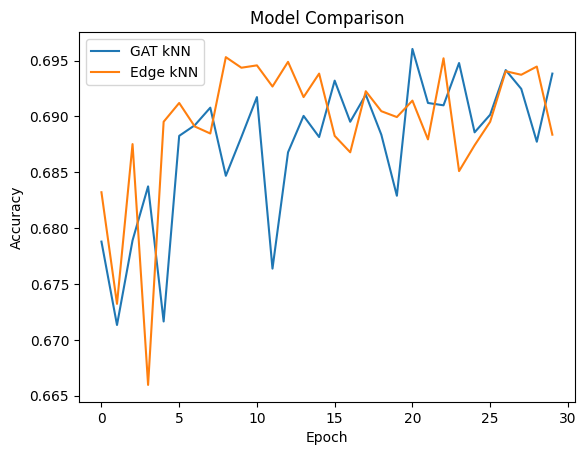

In [17]:
plt.plot(gat_test_knn_acc, label="GAT kNN")
plt.plot(edge_test_knn_acc, label="Edge kNN")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Model Comparison")
plt.show()

In [18]:
from sklearn.metrics import roc_auc_score

def compute_auc(model, loader):
    model.eval()
    y_true = []
    y_scores = []

    for data in loader:
        data = data.to(device)
        out = model(data.x, data.edge_index, data.batch)
        probs = torch.softmax(out, dim=1)[:, 1]

        y_true.extend(data.y.cpu().numpy())
        y_scores.extend(probs.detach().cpu().numpy())

    return roc_auc_score(y_true, y_scores)

print("GAT AUC:", compute_auc(gat_knn, test_loader_knn))
print("EdgeConv AUC:", compute_auc(edge_knn, test_loader_knn))

GAT AUC: 0.7536953668358217
EdgeConv AUC: 0.7500404421342969


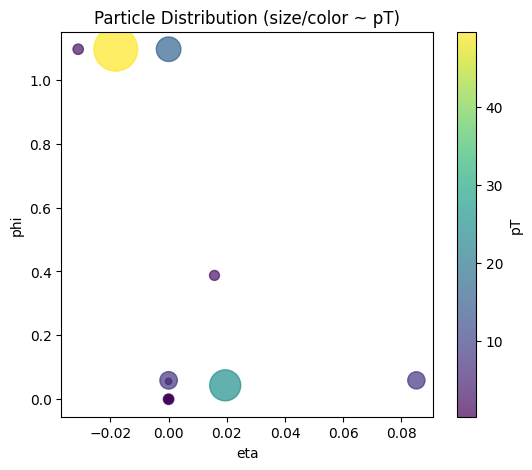

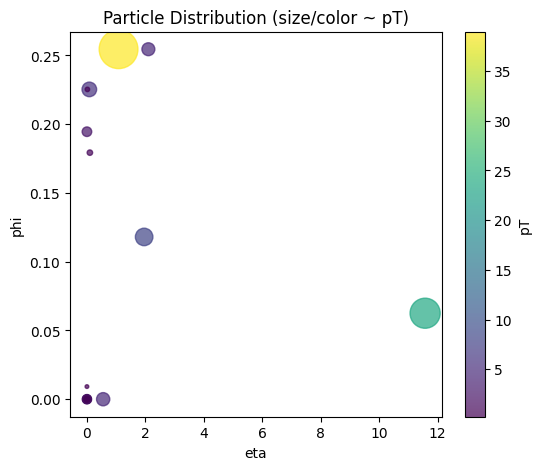

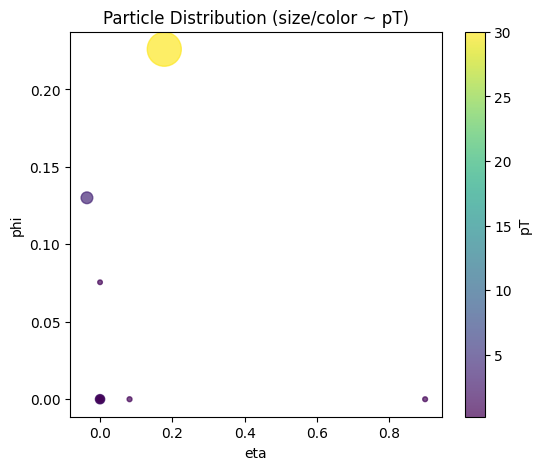

In [20]:
def plot_particles_pt(particles):
    eta = particles[:, 2]
    phi = particles[:, 3]
    pt  = particles[:, 0]

    plt.figure(figsize=(6,5))
    plt.scatter(
        eta,
        phi,
        s=pt * 20,          # size ~ pT
        c=pt,               # color ~ pT
        cmap="viridis",
        alpha=0.7
    )
    plt.colorbar(label="pT")
    plt.xlabel("eta")
    plt.ylabel("phi")
    plt.title("Particle Distribution (size/color ~ pT)")
    plt.show()

batch = next(pf.iter_batches(batch_size=3))
df_batch = batch.to_pandas()

for i in range(len(df_batch)):
    jet = df_batch.iloc[i]["X_jets"]
    particles = jet_to_particles(jet)
    plot_particles_pt(particles)

## Results

| Model     | Accuracy | AUC   |
|----------|---------|-------|
| GAT      | 0.6960  | 0.7537 |
| EdgeConv | 0.6953  | 0.7500 |  

## Observations

In this dataset split (run1), GAT slightly outperforms EdgeConv in both accuracy and AUC.  

This contrasts with previous results (run0), where EdgeConv showed better performance.  

This indicates that model performance is sensitive to variations in data distribution.  

## Analysis

The variation in performance across dataset splits suggests that:

- EdgeConv performs well when local geometric structure is dominant
- GAT performs better when adaptive weighting of particle interactions is beneficial

This highlights that different models capture complementary aspects of jet structure.

Such variability is expected in particle physics due to stochastic event generation and detector noise.


## Conclusion

This experiment demonstrates that model performance varies across dataset splits, emphasizing the importance of evaluating models on multiple independent samples.

While both GAT and EdgeConv perform comparably, their relative performance depends on the underlying data distribution.

This suggests that combining or selecting models based on data characteristics could further improve performance.